In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

# Load FINAL dataset
df = pd.read_csv(r"D:\capstone project dataset\11.01 final\CRA_DATASET_FIXED.csv")

In [2]:
from sklearn.preprocessing import StandardScaler

stress_features = [
    "Heatwave_Days",
    "Dry_Spell_Count",
    "Temp_Anomaly"
]

scaler = StandardScaler()
df["Climate_Stress_Index"] = scaler.fit_transform(
    df[stress_features]
).mean(axis=1)


In [3]:
high_stress = df["Climate_Stress_Index"].quantile(0.66)
low_stress  = df["Climate_Stress_Index"].quantile(0.33)

high_yield = df["Yield_kg_per_ha"].quantile(0.66)
low_yield  = df["Yield_kg_per_ha"].quantile(0.33)

def classify_resilience(row):
    if row["Climate_Stress_Index"] >= high_stress and row["Yield_kg_per_ha"] >= high_yield:
        return "High"
    elif row["Climate_Stress_Index"] >= high_stress and row["Yield_kg_per_ha"] <= low_yield:
        return "Low"
    else:
        return "Medium"

df["Resilience_Class"] = df.apply(classify_resilience, axis=1)

df["Resilience_Class"].value_counts()


Resilience_Class
Medium    14942
Low        2934
High       2410
Name: count, dtype: int64

In [4]:
DROP_FOR_CLASSIFIER = [
    "Yield_kg_per_ha",
    "Yield_Z_Score",
    "Yield_log",
    "Nutrient_Intensity",
    "N", "P", "K"
]

X_cls = df.drop(columns=[c for c in DROP_FOR_CLASSIFIER if c in df.columns])
y_cls = df["Resilience_Class"]

X_cls = pd.get_dummies(X_cls, drop_first=True)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)


In [6]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        High       0.95      1.00      0.97       482
         Low       1.00      0.99      0.99       587
      Medium       1.00      0.99      1.00      2989

    accuracy                           0.99      4058
   macro avg       0.98      0.99      0.99      4058
weighted avg       0.99      0.99      0.99      4058



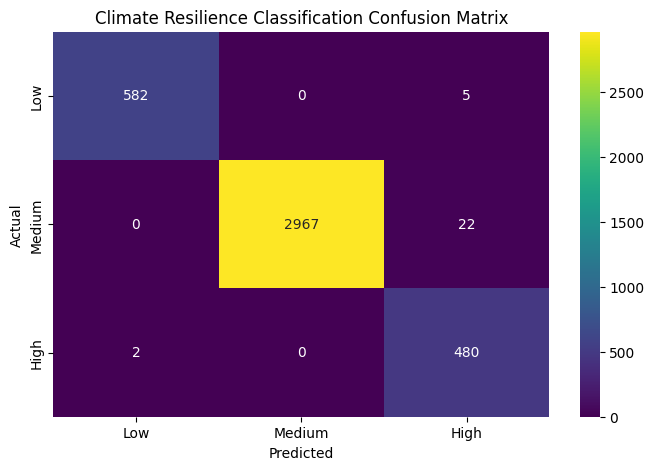

In [8]:
cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
    cmap="viridis"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Climate Resilience Classification Confusion Matrix")
plt.show()


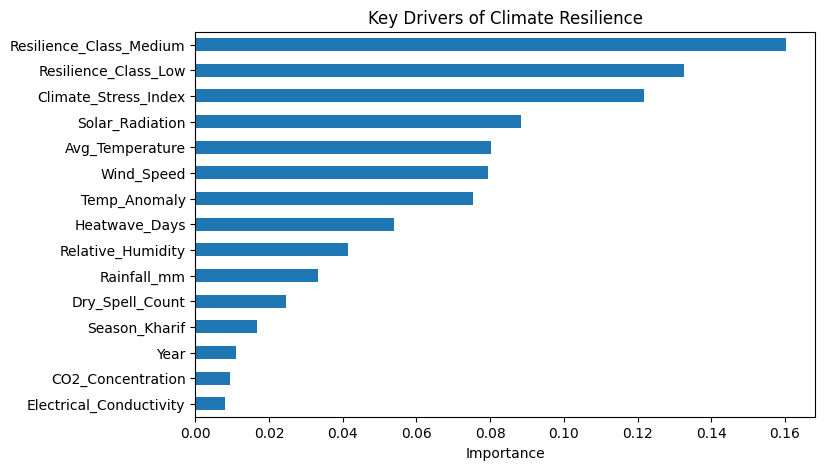

Resilience_Class_Medium    0.160216
Resilience_Class_Low       0.132719
Climate_Stress_Index       0.121866
Solar_Radiation            0.088468
Avg_Temperature            0.080231
Wind_Speed                 0.079441
Temp_Anomaly               0.075296
Heatwave_Days              0.053914
Relative_Humidity          0.041434
Rainfall_mm                0.033348
Dry_Spell_Count            0.024494
Season_Kharif              0.016669
Year                       0.010966
CO2_Concentration          0.009324
Electrical_Conductivity    0.007937
dtype: float64

In [9]:
importances = pd.Series(
    clf.feature_importances_,
    index=X_cls.columns
).sort_values(ascending=False)

top_features = importances.head(15)

plt.figure(figsize=(8,5))
top_features.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Key Drivers of Climate Resilience")
plt.show()

top_features


In [10]:
import joblib

joblib.dump(clf, "CRA_Final_Resilient_Classifier_Model.joblib")
print("Final yield model saved ✅")


Final yield model saved ✅
